### Synthetic Data Generation Via Euler–Maruyama Monte Carlo Simulation

```
┌─────────────────────────────────────────────────────────┐
│  SETUP                                                  │
│  Set ℙ params: μ, κ, α_P, σ₁, σ₂, ρ                     │
│  Set ℚ params: r, λ₂  →  α_Q = α_P - σ₂λ₂/κ             │
│  Set S₀=100, T=10, N=1000, M=100                        │
│  dt = T/N,  t = [0, dt, 2dt, ..., T]  (N+1 points)      │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  INITIALISE STATE ARRAYS  (M × N+1)                     │
│  X[:,0]     = ln(S₀)   for all M paths                  │
│  δ[:,0]     = α_P      for all M paths                  │
│  Seed PRNG: key = PRNGKey(0)                            │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  EULER–MARUYAMA LOOP  (under ℙ)   n = 0, 1, ..., N-1    │
│                                                         │
│  1. Split key → subkey0, subkey1                        │
│                                                         │
│  2. Draw independent normals (shape M):                 │
│       z₀, z₁ ~ N(0,1)                                   │
│                                                         │
│  3. Cholesky-correlated Brownian increments:            │
│       dW₁ = √dt · z₀                                    │
│       dW₂ = √dt · (ρ·z₀ + √(1-ρ²)·z₁)                   │
│       → Cov(dW₁, dW₂) = ρ·dt  ✓                         │
│                                                         │
│  4. Euler step — log spot (Itô-corrected):              │
│       X_{n+1} = X_n + (μ - δ_n - ½σ₁²)dt + σ₁·dW₁       │
│                       └── Itô correction ──┘            │
│                                                         │
│  5. Euler step — convenience yield (OU process):        │
│       δ_{n+1} = δ_n + κ(α_P - δ_n)dt + σ₂·dW₂           │
│                        └── mean reversion ──┘           │
└─────────────────────┬───────────────────────────────────┘
                      │  (after N steps)
                      ▼
┌─────────────────────────────────────────────────────────┐
│  RECOVER SPOT PRICE                                     │
│  S = exp(X)    shape: M × N+1                           │
└─────────────────────┬───────────────────────────────────┘
                      │
          ┌───────────┴──────────────┐
          │  MEASURE SWITCH: ℙ → ℚ   │
          └───────────┬──────────────┘
                      ▼
┌─────────────────────────────────────────────────────────┐
│  PRICE FUTURES PANEL  (closed form under ℚ)             │
│  For every (path, date, maturity) triple:               │
│    F(τ, S, δ) = S · exp(B(τ)·δ + A(τ))                  │
│  F_clean shape: M × N+1 × K   (K=12 maturities)         │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  ADD OBSERVATION NOISE                                  │
│  log_F_obs = log(F_clean) + ε,  ε ~ N(0, σ_noise²)      │
└─────────────────────┬───────────────────────────────────┘
                      │
                      ▼
┌─────────────────────────────────────────────────────────┐
│  SAVE  mc_data.pkl                                      │
│  ├── S, log_F_obs          → PINN sees these only       │
│  ├── params_P, params_Q    → known / given              │
│  └── delta_true            → eval target, never to PINN │
└─────────────────────────────────────────────────────────┘
```


In [42]:
# closed-form GS futures pricer
from gs_wamol.physics.gibson_schwartz import GSParams, futures, term_structure
import jax.numpy as jnp
from jax import random, vmap
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [43]:
# P-measure params, Table VI col. I in Schwartz (1997): WTI F1-F9, 1/2/85-12/17/95
p_params = {
    "mu": 0.142,
    "kappa": 1.876,
    "alpha_P": 0.106,
    "sigma1": 0.393,
    "sigma2": 0.527,
    "rho": 0.766
}

# Q-measure pricing params
r = 0.05
lambda2 = 0.10  # market price of risk, not pinned by no-arbitrage
alpha_Q = p_params["alpha_P"] - p_params["sigma2"] * lambda2 / p_params["kappa"]  # measure-change formula


S0 = 100.0  # initial spot price
T = 10.0  # simulated horizon, years
N = 1000  # time steps
M = 100   # paths

dt = T / N # time step size
sqrt_dt = jnp.sqrt(dt)
t = jnp.linspace(0, T, N + 1) # time grid t=0 to T, inclusive

# state arrays, shape (paths, dates). delta mean-reverts strongly to alpha_P, so start there
X = jnp.zeros((M, N + 1))
delta = jnp.zeros((M, N + 1))
delta = delta.at[:, 0].set(p_params["alpha_P"] * jnp.ones(M)) # delta begins at its long-run mean
X = X.at[:, 0].set(jnp.log(S0) * jnp.ones(M))  # log spot price

key = random.PRNGKey(0)
dW1_list, dW2_list = [], []
for n in range(N):
    key, subkey0, subkey1 = random.split(key, 3)
    z0 = random.normal(subkey0, shape=(M,))
    z1 = random.normal(subkey1, shape=(M,))
    dW1 = sqrt_dt * z0
    dW1_list.append(dW1)
    dW2 = (p_params["rho"] * z0 + jnp.sqrt(1 - p_params["rho"] ** 2) * z1) * sqrt_dt  # Cholesky-correlated with dW1
    dW2_list.append(dW2)

    # Euler-Maruyama step for log spot and convenience yield
    X = X.at[:, n + 1].set(X[:, n] + (p_params["mu"] - delta[:, n] - 0.5 * p_params["sigma1"] ** 2) * dt + p_params["sigma1"] * dW1)
    delta = delta.at[:, n + 1].set(delta[:, n] + p_params["kappa"] * (p_params["alpha_P"] - delta[:, n]) * dt + p_params["sigma2"] * dW2)

# stack the per-step increments to (M, N) and check the realised correlation matches rho
dW1_all = jnp.stack(dW1_list, axis=1)
dW2_all = jnp.stack(dW2_list, axis=1)
corr = jnp.corrcoef(dW1_all.ravel(), dW2_all.ravel())[0, 1]

print(f"Correlation between dW1 and dW2: {corr:.4f}")
print(f"Mean of delta at final time step: {delta[:, -1].mean():.4f}")  # should sit near alpha_P
print(jnp.all(jnp.exp(X) > 0))  # spot must stay positive

Correlation between dW1 and dW2: 0.7653
Mean of delta at final time step: 0.0766
True


In [ ]:
S = jnp.exp(X)  # (M, N+1) spot price paths, out of log space for the pricer

# fixed maturities held constant across dates (CL1..CL12-style panel),
# same convention as data/generate.py / data/observe.py
taus = jnp.arange(1, 13) / 12.0  # (K,) years: 1mo, 2mo, ..., 12mo
K = taus.shape[0]

p_Q = GSParams(r=r, kappa=p_params['kappa'], alpha_Q=alpha_Q, sigma1=sigma1, sigma2=sigma2, rho=rho)

def price_curve(S_pt, delta_pt):
    # S_pt, delta_pt are scalars: one path, one date. term_structure vmaps the
    # closed-form futures() over the maturity axis internally.
    return term_structure(taus, S_pt, delta_pt, p_Q)  # (K,)

# vmap over dates, then over paths, pricing every (path, date) state across all K maturities
price_over_dates = vmap(price_curve, in_axes=(0, 0))       # (N+1,) x (N+1,) -> (N+1, K)
price_over_paths = vmap(price_over_dates, in_axes=(0, 0))  # (M, N+1) x (M, N+1) -> (M, N+1, K)

F_clean = price_over_paths(S, delta)  # (M, N+1, K) exact closed-form futures prices
log_F_clean = jnp.log(F_clean)        # log-price panel, matches observe.py's convention

# add measurement noise to simulate observed market quotes (for PINN inversion downstream)
noise_std = 0.01
key, noise_key = random.split(key)
log_F_obs = log_F_clean + noise_std * random.normal(noise_key, shape=log_F_clean.shape)

# sanity check 1: F_hat(tau=0, S, delta) should equal S exactly (the pricing PDE's
# initial condition). float32 (JAX default) floors this around ~1e-5.
ic_err = float(jnp.max(jnp.abs(futures(0.0, S[:, 0], delta[:, 0], p_Q) - S[:, 0])))
print(f"F_hat(tau=0) - S initial-condition error: {ic_err:.2e}")

# sanity check 2: the shortest maturity (1mo) should sit closer to spot in log-price
# than the longest (12mo), since |B(tau)| grows monotonically with tau
log_S = jnp.log(S)
dev_short = jnp.abs(log_F_clean[:, :, 0] - log_S)
dev_long = jnp.abs(log_F_clean[:, :, -1] - log_S)
frac_ok = float(jnp.mean(dev_short <= dev_long))
print(f"F_clean sanity: short-maturity closer to spot than long-maturity in {frac_ok:.1%} of (path, date) cells")

# NOTE: taus is fixed and held constant across every simulated date, so at the last
# date the 12mo contract prices a state maturing beyond the simulated horizon. This is
# intentional: the closed-form pricer only needs the current (S, delta) state and tau,
# not simulated paths out to delivery.

F_hat(tau=0) - S initial-condition error: 0.00e+00
F_clean sanity: short-maturity closer to spot than long-maturity in 95.9% of (path, date) cells


In [45]:
import pickle

mc_data = {
    't_grid': t,                  # (N+1,) simulation dates
    'taus': taus,                 # (K,) fixed contract maturities, years
    'S': S,                       # (M, N+1) spot price paths
    'delta_true': delta,          # (M, N+1) TRUE latent convenience yield -- eval target only, never feed to inversion
    'F_clean': F_clean,           # (M, N+1, K) exact closed-form futures prices
    'log_F_obs': log_F_obs,       # (M, N+1, K) noisy observed log futures prices
    'params_Q': p_Q,
    'params_P': dict(mu=mu, kappa=kappa, alpha_P=alpha_P, sigma1=sigma1, sigma2=sigma2, rho=rho),
    'alpha_Q': alpha_Q,
    'lambda2': lambda2,
}

with open('mc_data.pkl', 'wb') as f:
    pickle.dump(mc_data, f)

print(f"F_clean shape     : {mc_data['F_clean'].shape}  (paths, dates, maturities)")
print(f"delta_true shape  : {mc_data['delta_true'].shape}  (retained as eval target)")

F_clean shape     : (100, 1001, 12)  (paths, dates, maturities)
delta_true shape  : (100, 1001)  (retained as eval target)


In [46]:
colors = cm.viridis(jnp.linspace(0, 1, M))  # one color per path, for the plots below

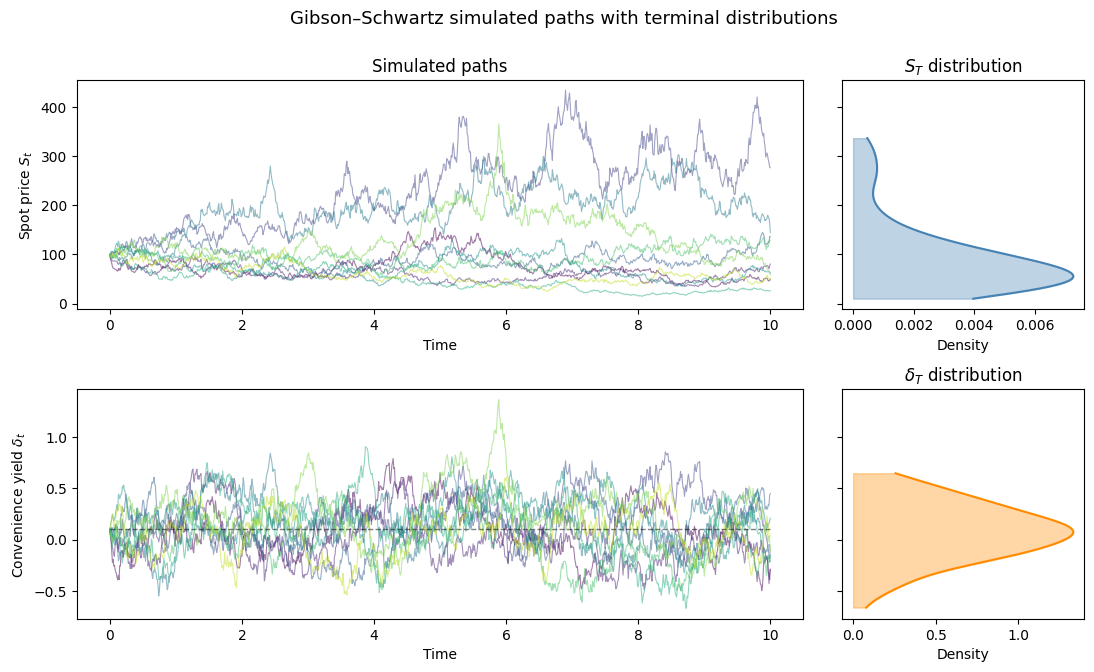

In [47]:
import numpy as np
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 2, width_ratios=[3, 1], hspace=0.35, wspace=0.08)

ax_s      = fig.add_subplot(gs[0, 0])
ax_s_dist = fig.add_subplot(gs[0, 1], sharey=ax_s)
ax_d      = fig.add_subplot(gs[1, 0])
ax_d_dist = fig.add_subplot(gs[1, 1], sharey=ax_d)

# spot price paths (every 10th path for clarity)
for i in range(0, M, 10):
    ax_s.plot(t, jnp.exp(X[i, :]), color=colors[i], alpha=0.5, lw=0.8)
ax_s.set_ylabel('Spot price $S_t$')
ax_s.set_xlabel('Time')
ax_s.set_title('Simulated paths')

# KDE of S_T, the terminal distribution
S_T = np.array(jnp.exp(X[:, -1]))
s_vals = np.linspace(S_T.min(), S_T.max(), 300)
kde_s = gaussian_kde(S_T)
ax_s_dist.fill_betweenx(s_vals, kde_s(s_vals), alpha=0.35, color='steelblue')
ax_s_dist.plot(kde_s(s_vals), s_vals, color='steelblue', lw=1.5)
ax_s_dist.set_xlabel('Density')
ax_s_dist.set_title('$S_T$ distribution')
ax_s_dist.tick_params(labelleft=False)

# convenience yield paths
for i in range(0, M, 10):
    ax_d.plot(t, delta[i, :], color=colors[i], alpha=0.5, lw=0.8)
ax_d.set_ylabel('Convenience yield $\\delta_t$')
ax_d.set_xlabel('Time')
ax_d.hlines(y=alpha_P, color='black', lw=1.0, ls='--', alpha=0.5, xmin=t[0], xmax=t[-1])  # reference line at alpha_P

# KDE of delta_T, the terminal distribution
delta_T = np.array(delta[:, -1])
d_vals = np.linspace(delta_T.min(), delta_T.max(), 300)
kde_d = gaussian_kde(delta_T)
ax_d_dist.fill_betweenx(d_vals, kde_d(d_vals), alpha=0.35, color='darkorange')
ax_d_dist.plot(kde_d(d_vals), d_vals, color='darkorange', lw=1.5)
ax_d_dist.set_xlabel('Density')
ax_d_dist.set_title('$\\delta_T$ distribution')
ax_d_dist.tick_params(labelleft=False)

fig.suptitle('Gibson–Schwartz simulated paths with terminal distributions', fontsize=13)
plt.show()

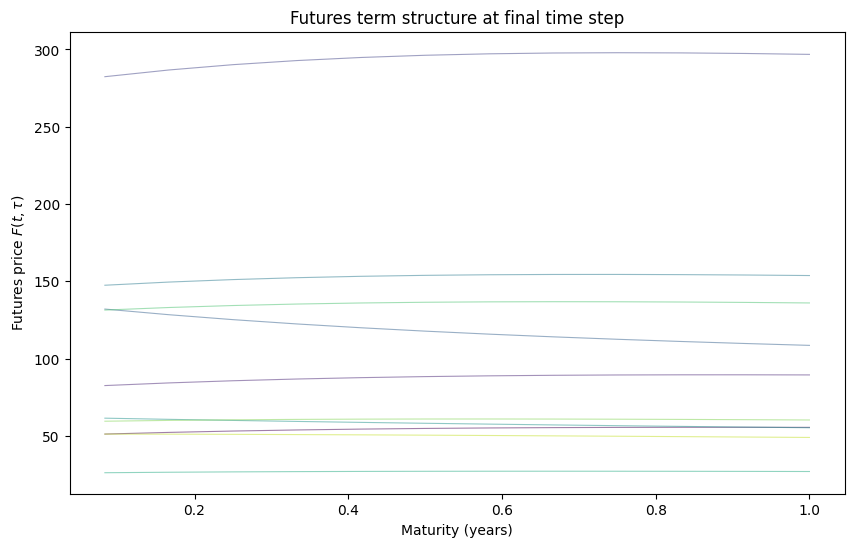

In [48]:
fig, axes = plt.subplots(1, 1, figsize=(10, 6))
# plot the futures term structure at the final time step for a few paths
for i in range(0, M, 10):
    axes.plot(taus, F_clean[i, -1, :], color=colors[i], alpha=0.5, lw=0.8)
axes.set_xlabel('Maturity (years)')
axes.set_ylabel('Futures price $F(t, \\tau)$')
axes.set_title('Futures term structure at final time step')
plt.show()